# Phase 2: Calibration and Threshold Transfer

CPU only. Set Accelerator = None, Internet = Off.
Add Data > Your Work > attach the Phase 1 notebook output (`logits.npz`).

Sections 1 to 3 reproduce known results. **Section 4 is the contribution.**

In [1]:
import glob, os, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

hits = glob.glob("/kaggle/input/**/*.npz", recursive=True)
if not hits:
    print("Nothing found. /kaggle/input contains:")
    for r,_,f in os.walk("/kaggle/input"): print(" ", r, f[:6])
    raise SystemExit("Attach the Phase 1 notebook output: Add Data > Your Work.")
p = [h for h in hits if h.endswith("logits.npz")] or hits
p = p[0]; print("using", p)

d = np.load(p); SEEDS = [0,1,2]
CORRUPTIONS = ["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
               "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
               "elastic_transform","pixelate","jpeg_compression"]
missing = [k for k in ["y_val","y_test","y_corr","val_0","test_0"] if k not in d]
assert not missing, f"npz is missing {missing} - wrong file?"

def softmax(z, T=1.0):
    z = z.astype(np.float64)/T; z -= z.max(1, keepdims=True)
    e = np.exp(z); return e/e.sum(1, keepdims=True)

def get(key, seed=0):
    y = d["y_test"] if key=="test" else d["y_val"] if key=="val" else d["y_corr"]
    return d[f"{key}_{seed}"], y

CELLS = [("test", 0)] + [(c_, s) for s in range(1,6) for c_ in CORRUPTIONS]
print(len(CELLS), "cells")

using /kaggle/input/notebooks/shayamahmad74/phase-1-sep-14/logits.npz
76 cells


## 1. Metrics

In [2]:
def ece(prob, y, bins=15):
    conf, pred = prob.max(1), prob.argmax(1); corr = (pred==y)
    edges = np.linspace(0,1,bins+1); e = 0.0
    for lo,hi in zip(edges[:-1], edges[1:]):
        m = (conf>lo)&(conf<=hi)
        if m.sum(): e += m.mean()*abs(corr[m].mean()-conf[m].mean())
    return e

def brier(prob, y):
    oh = np.eye(prob.shape[1])[y]; return ((prob-oh)**2).sum(1).mean()

def nll(prob, y):
    return -np.log(np.clip(prob[np.arange(len(y)), y], 1e-12, None)).mean()

## 2. Temperature scaling, fit on clean validation only

In [3]:
def fit_T(lg, y):
    f = lambda t: nll(softmax(lg, t), y)
    return minimize_scalar(f, bounds=(0.5, 10.0), method="bounded").x

lg_v, y_v = get("val")
T_star = fit_T(lg_v, y_v)
print(f"T* = {T_star:.3f}  (>1 means the model was overconfident)")

T* = 1.468  (>1 means the model was overconfident)


In [4]:
rows = []
for sev in range(6):
    keys = [("test",0)] if sev==0 else [(c_,sev) for c_ in CORRUPTIONS]
    pre = post = acc = 0.0
    for k,s in keys:
        lg, y = get("test" if sev==0 else f"{k}_{s}")
        pre  += ece(softmax(lg, 1.0), y); post += ece(softmax(lg, T_star), y)
        acc  += (lg.argmax(1)==y).mean()
    n = len(keys); rows.append((sev, acc/n, pre/n, post/n))

print(f"{'sev':>3} {'acc':>7} {'ECE':>8} {'ECE+T':>8} {'change':>8}")
for sev,a,pre,post in rows:
    print(f"{sev:>3} {a*100:6.1f}% {pre:8.4f} {post:8.4f} {(post-pre)/pre*100:+7.1f}%")

sev     acc      ECE    ECE+T   change
  0   94.4%   0.0304   0.0074   -75.8%
  1   86.6%   0.0813   0.0456   -43.8%
  2   80.7%   0.1216   0.0773   -36.4%
  3   74.5%   0.1650   0.1127   -31.7%
  4   67.0%   0.2160   0.1546   -28.4%
  5   55.4%   0.2974   0.2227   -25.1%


Expect temperature scaling to cut ECE sharply at severity 0 and help less, or hurt,
as severity rises. That is the Ovadia finding reproduced on your own models.

## 3. Selective prediction baseline

Risk = error rate among accepted predictions. Coverage = fraction accepted.

In [5]:
def risk_cov(prob, y, thr):
    conf, pred = prob.max(1), prob.argmax(1); acc = conf >= thr
    if acc.sum()==0: return np.nan, 0.0
    return 1-(pred[acc]==y[acc]).mean(), acc.mean()

def threshold_for_risk(prob, y, target):
    """Smallest threshold on THIS data achieving <= target risk (max coverage)."""
    for t in np.sort(prob.max(1)):
        r,_ = risk_cov(prob, y, t)
        if r <= target: return t
    return 1.0

TARGET = 0.05
p_v = softmax(lg_v, T_star)
thr = threshold_for_risk(p_v, y_v, TARGET)
print(f"threshold from clean val = {thr:.4f}, val risk/cov = "
      f"{risk_cov(p_v, y_v, thr)[0]:.3f} / {risk_cov(p_v, y_v, thr)[1]:.3f}")

threshold from clean val = 0.4623, val risk/cov = 0.050 / 0.992


## 4. Threshold transfer: the contribution

The threshold above was chosen on clean labelled data, exactly as deployment
practice dictates. Now measure what risk it actually delivers under shift,
where no labels exist to check it.

In [6]:
def eval_all(score_fn, thr):
    out = {}
    for k,s in CELLS:
        prob, y = score_fn(k, s)
        out[(k,s)] = risk_cov(prob, y, thr)
    return out

single = lambda k,s: (softmax(get("test" if k=="test" else f"{k}_{s}")[0], T_star),
                      d["y_test"] if k=="test" else d["y_corr"])

res = eval_all(single, thr)
print(f"{'sev':>3} {'risk':>8} {'target':>7} {'cov':>7} {'violated':>9}")
for sev in range(6):
    ks = [(k,s) for k,s in CELLS if s==sev] if sev else [("test",0)]
    r = np.array([res[k][0] for k in ks]); cv = np.array([res[k][1] for k in ks])
    print(f"{sev:>3} {np.nanmean(r):7.3f} {TARGET:7.3f} {cv.mean():7.3f} "
          f"{(r>TARGET).mean()*100:7.0f}%")

sev     risk  target     cov  violated
  0   0.050   0.050   0.990     100%
  1   0.121   0.050   0.972     100%
  2   0.174   0.050   0.958     100%
  3   0.233   0.050   0.942     100%
  4   0.304   0.050   0.919     100%
  5   0.419   0.050   0.885     100%


In [7]:
# Which corruptions break it worst, at severity 5
worst = sorted(((res[(c_,5)][0], res[(c_,5)][1], c_) for c_ in CORRUPTIONS), reverse=True)
print(f"{'corruption':>20} {'risk':>7} {'cov':>7}   (target 0.05)")
for r,cv,c_ in worst: print(f"{c_:>20} {r:7.3f} {cv:7.3f}")

          corruption    risk     cov   (target 0.05)
       impulse_noise   0.745   0.719
      gaussian_noise   0.717   0.818
            contrast   0.676   0.764
          shot_noise   0.638   0.814
          glass_blur   0.503   0.859
            pixelate   0.489   0.897
        defocus_blur   0.443   0.908
               frost   0.364   0.920
           zoom_blur   0.354   0.922
         motion_blur   0.331   0.926
    jpeg_compression   0.258   0.931
   elastic_transform   0.229   0.934
                 fog   0.225   0.942
                snow   0.224   0.944
          brightness   0.083   0.981


## 5. Does a deep ensemble hold up better?

In [8]:
def ens(k, s):
    key = "test" if k=="test" else f"{k}_{s}"
    prob = np.mean([softmax(d[f"{key}_{sd}"], T_star) for sd in SEEDS], axis=0)
    return prob, (d["y_test"] if k=="test" else d["y_corr"])

p_v_ens = np.mean([softmax(d[f"val_{sd}"], T_star) for sd in SEEDS], axis=0)
thr_e = threshold_for_risk(p_v_ens, y_v, TARGET)
res_e = eval_all(ens, thr_e)

print(f"{'sev':>3} {'single risk':>12} {'ens risk':>10} {'single cov':>11} {'ens cov':>9}")
for sev in range(6):
    ks = [(k,s) for k,s in CELLS if s==sev] if sev else [("test",0)]
    print(f"{sev:>3} {np.nanmean([res[k][0] for k in ks]):12.3f} "
          f"{np.nanmean([res_e[k][0] for k in ks]):10.3f} "
          f"{np.mean([res[k][1] for k in ks]):11.3f} "
          f"{np.mean([res_e[k][1] for k in ks]):9.3f}")

sev  single risk   ens risk  single cov   ens cov
  0        0.050      0.048       0.990     1.000
  1        0.121      0.118       0.972     0.998
  2        0.174      0.172       0.958     0.998
  3        0.233      0.233       0.942     0.997
  4        0.304      0.306       0.919     0.996
  5        0.419      0.422       0.885     0.994


## 6. Plot

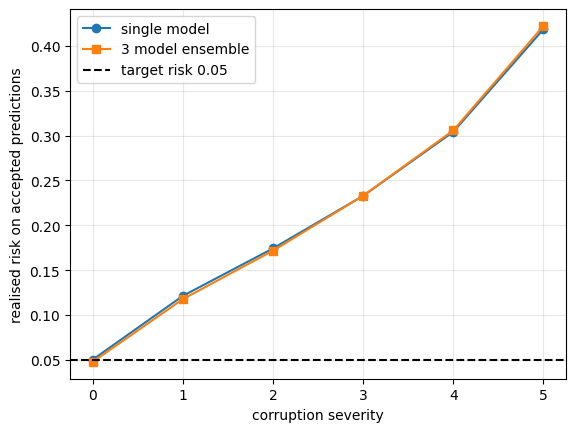

In [9]:
sevs = range(6)
f = lambda R: [np.nanmean([R[k][0] for k in ([(k_,s) for k_,s in CELLS if s==sv] if sv else [("test",0)])]) for sv in sevs]
plt.plot(sevs, f(res), "o-", label="single model")
plt.plot(sevs, f(res_e), "s-", label="3 model ensemble")
plt.axhline(TARGET, ls="--", c="k", label=f"target risk {TARGET}")
plt.xlabel("corruption severity"); plt.ylabel("realised risk on accepted predictions")
plt.legend(); plt.grid(alpha=.3); plt.show()

## 7. Per class abstention

Does the rejector refuse disproportionately on some classes? If so the system
fails invisibly for a subset of inputs, which is a second finding.

In [10]:
names = ["plane","car","bird","cat","deer","dog","frog","horse","ship","truck"]
prob, y = ens("gaussian_noise", 3)
acc_mask = prob.max(1) >= thr_e
print(f"{'class':>7} {'coverage':>9} {'risk|acc':>9}")
for i,n in enumerate(names):
    m = y==i; a = acc_mask & m
    r = 1-(prob[a].argmax(1)==y[a]).mean() if a.sum() else np.nan
    print(f"{n:>7} {a.sum()/m.sum():9.3f} {r:9.3f}")

  class  coverage  risk|acc
  plane     0.998     0.846
    car     0.995     0.670
   bird     1.000     0.303
    cat     0.998     0.841
   deer     1.000     0.536
    dog     0.999     0.945
   frog     0.999     0.055
  horse     0.999     0.819
   ship     0.999     0.649
  truck     0.994     0.641


## What to record

For the writeup: the severity at which realised risk first exceeds target, the
worst case corruption, how much coverage was spent, and whether the ensemble
delays the failure or only softens it. If the ensemble merely delays it, the
honest conclusion is that no current score gives a usable risk guarantee under
shift, which is a publishable negative result.